### Pearson's correlations between agent's (PopCensus) lexical analysis scores and HEXACO-PI-R 100 scores.

In [1]:
from support.validity_support import read_in_lexical_scores, read_in_loadings, calculate_agent_scores
from support.pca_support import popc_10_factor_labels

lexical_scores = read_in_lexical_scores('data/popc_results.csv')
factor_loadings = read_in_loadings('intermediate/loadings_popc_10.csv', popc_10_factor_labels)

# using pca recovered loadings, calculate scores for each agent for each factor.
df_lexical = calculate_agent_scores(lexical_scores, factor_loadings)

# now select the 6 factors from the 10 factor solution that most closely align
# with the original Hexaco dimensions (1-Dishonesty, 2-Disagreeableness, 3-Introversion, 
# 4-Unconscientiousness, 6-Unscholarly (Openness) and 7-Gendered-emotionality).  
# These factors were selected using the weighted jaccard similarity values, see 
# PopCensus-10Factor-Results.ipynb for details.

# rename and reorder them so they match the original hexaco structure.
reduced_df = df_lexical[['Dishonesty', 'Gendered-emotionality', 'Introversion', 
                         'Disagreeableness', 'Unconscientiousness', 'Unscholarly']]
reduced_df.columns = ['Honesty-Humility', 'Emotionality', 'Extraversion', 
                      'Agreeableness', 'Conscientiousness', 'Openness']


In [2]:
# Compare agent's lexical scores (derived from PopC's 10 factor solution) to their HEXACO-PI-R-100 results (for GPT-4)
import pandas as pd
from scipy.stats import pearsonr
from support.hexaco_pi_r import get_pir_scores

df = get_pir_scores("data/hexaco-pi-r-responses-GPT-4.csv")

# now for all hexaco dimensions, across all agent factors, report pearsons!   
results = pd.DataFrame(index=df.columns, columns=df_lexical.columns)
for hexaco_survey in df.columns:
    for agents_factor in df_lexical.columns:
        r, p_value = pearsonr(df[hexaco_survey], df_lexical[agents_factor])
        results.loc[hexaco_survey, agents_factor] = r

pp = pd.DataFrame(results)
pp = pp.astype(float).round(3)
pp

,Dishonesty,Disagreeableness,Introversion,Unconscientiousness,Unheroic,Unscholarly,Gendered-emotionality,Unsentimentality,Insensitivity,Unartistic
Honesty-Humility,-0.814,-0.185,0.182,-0.053,0.359,0.320,0.020,-0.495,-0.466,0.559
Emotionality,-0.328,-0.584,-0.573,0.350,0.097,-0.043,0.686,-0.528,-0.660,-0.165
Extraversion,0.151,-0.153,-0.833,0.339,-0.675,0.052,0.227,0.109,0.304,-0.511
Agreeableness,-0.173,-0.873,-0.357,0.437,0.234,-0.046,0.350,-0.509,-0.112,0.005
Conscientiousness,0.101,0.446,0.384,-0.934,0.246,-0.290,-0.195,0.190,0.082,-0.049
Openness,0.026,-0.329,-0.140,0.339,-0.044,-0.447,0.378,-0.309,-0.350,-0.386


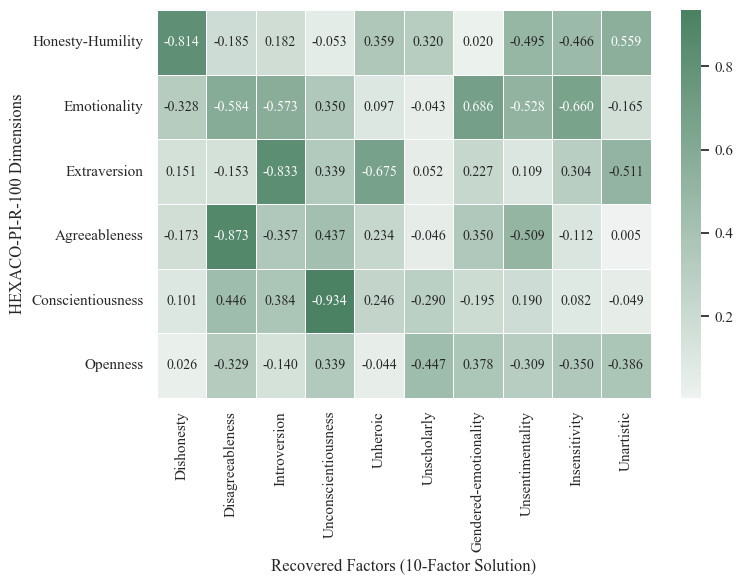

In [3]:
def plot_for_paper_figure_6(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    results_numeric = df.astype(float)
    annotations = results_numeric.map(lambda x: f"{'-' if x < 0 else ''}{abs(x):.3f}")

    sns.set_theme(style='white', font='Times New Roman')
    plt.figure(figsize=(8, 6))
    cm = sns.diverging_palette(300, 145, s=60, as_cmap=True)
    sns.heatmap(results_numeric.abs(), annot=annotations, fmt='', cmap=cm, center=0, linewidths=0.5, annot_kws={"size": 10})
    # plt.title('Correlation Heatmap of Agents\' HEXACO-PI-R-100 results and recovered lexical factors')
    plt.xlabel('Recovered Factors (10-Factor Solution)')
    plt.ylabel('HEXACO-PI-R-100 Dimensions')

    plt.tight_layout()
    plt.show()

plot_for_paper_figure_6(results)

### Pearson's correlations between lexical scores and HEXACO-PI-R-100 results, across all 4 models (Table 1)

In [4]:
import pandas as pd
from support.hexaco_pi_r import get_pir_scores
from support.validity_support import calc_pearsons_matching_factors

files = {"GPT-4": "data/hexaco-pi-r-responses-GPT-4.csv",
         "Sonnet": "data/hexaco-pi-r-responses-sonnet.csv",
         "Phi4": "data/hexaco-pi-r-responses-phi4.csv",
         "Llama3.2": "data/hexaco-pi-r-responses-llama3.2.csv",
         }

table = pd.DataFrame(index=files.keys(), columns=['Honesty-Humility',
                                                    'Emotionality',
                                                    'Extraversion',
                                                    'Agreeableness',
                                                    'Conscientiousness',
                                                    'Openness'])

r_values = pd.DataFrame(index=table.index, columns=table.columns)

for name, file in files.items():
    df = get_pir_scores(file)
    results = calc_pearsons_matching_factors(reduced_df, df)
    r_vals = [str(round(val, 3)) for val in results['r'].values]
    p_vals = ['p=' + str(round(val, 3)) for val in results['p'].values]
    zipped_vals = [f"{r} ({p})" for r, p in zip(r_vals, p_vals)]
    table.loc[name] = zipped_vals
    r_values.loc[name] = [abs(x) for x in results['r'].values]

table['Mean (abs)'] = [round(sum(r_values.loc[x])/6, 3) for x in r_values.index]
table.T

,GPT-4,Sonnet,Phi4,Llama3.2
Honesty-Humility,-0.814 (p=0.0),-0.768 (p=0.0),-0.851 (p=0.0),-0.214 (p=0.0)
Emotionality,0.686 (p=0.0),0.734 (p=0.0),0.557 (p=0.0),0.117 (p=0.039)
Extraversion,-0.833 (p=0.0),-0.773 (p=0.0),-0.84 (p=0.0),-0.231 (p=0.0)
Agreeableness,-0.873 (p=0.0),-0.868 (p=0.0),-0.852 (p=0.0),-0.36 (p=0.0)
Conscientiousness,-0.934 (p=0.0),-0.928 (p=0.0),-0.896 (p=0.0),-0.368 (p=0.0)
Openness,-0.447 (p=0.0),-0.433 (p=0.0),-0.278 (p=0.0),-0.013 (p=0.819)
Mean (abs),0.765,0.751,0.712,0.217
